<img src="Tarea.png" alt="Descripción" widt_pokeh="1500">


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


## Importación del Dataset y análisis general

In [3]:
# Path del dataset e importación del mismo

path_data_set = "Pokemon.csv"
dt_poke = pd.read_csv(path_data_set)


In [4]:
# Filas y columnas 

filas, columnas = dt_poke.shape
print(f"El Dataset tiene {filas} filas y {columnas} columnas")

El Dataset tiene 800 filas y 13 columnas


In [ ]:
#Nombre de las columnas

nombres_columnas = dt_poke.columns
print(f"Las columnas son {nombres_columnas}")

Las columnas son Index(['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='str')


In [ ]:
# Visualización general

dt_poke.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [10]:
# Información general
dt_poke.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      414 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    int64
 10  Speed       800 non-null    int64
 11  Generation  800 non-null    int64
 12  Legendary   800 non-null    bool 
dtypes: bool(1), int64(9), str(3)
memory usage: 75.9 KB


In [ ]:
variables_numericas = ['Total', 'HP','Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
variables_cat_nom =['Type 1', 'Type 2', 'Legendary']
variables_cat_ord = ['Generation']
variables_nombres = ['Name'] # Esta variable no la consideraría en ninguno de los otro sos

In [ ]:
#Convertir a category
dt_poke['Name'] = dt_poke['Name'].astype('category')
dt_poke['Type 1'] = dt_poke['Type 1'].astype('category')
dt_poke['Type 2'] = dt_poke['Type 2'].astype('category')
dt_poke['Generation'] = dt_poke['Generation'].astype('category')

In [13]:
# Describe de las categóricas
dt_poke.describe(include='category')





,Name,Type 1,Type 2,Generation
count,800,800,414,800
unique,800,18,18,6
top,Abomasnow,Water,Flying,1
freq,1,112,97,166


In [ ]:
print(f"Frecuencias de la variable 'Type 1': {dt_poke['Type 1'].value_counts()}")


Frecuencias de la variable 'estacion': Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Dragon       32
Ghost        32
Ground       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64


In [16]:
print(f"Frecuencias de la variable 'Type 1': {dt_poke['Type 2'].value_counts()}")


Frecuencias de la variable 'Type 1': Type 2
Flying      97
Ground      35
Poison      34
Psychic     33
Fighting    26
Grass       25
Fairy       23
Steel       22
Dark        20
Dragon      18
Ghost       14
Ice         14
Rock        14
Water       14
Fire        12
Electric     6
Normal       4
Bug          3
Name: count, dtype: int64


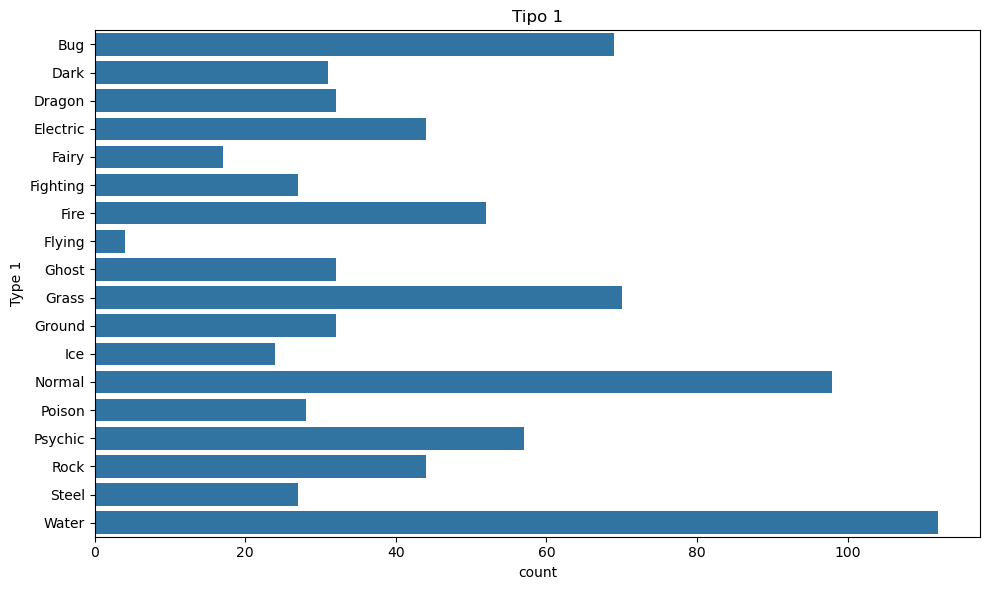

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.countplot(y='Type 1', data=dt_poke, ax=ax)
ax.set_title('Tipo 1')
plt.tight_layout()
plt.show()

## Relacion entre algunas variables

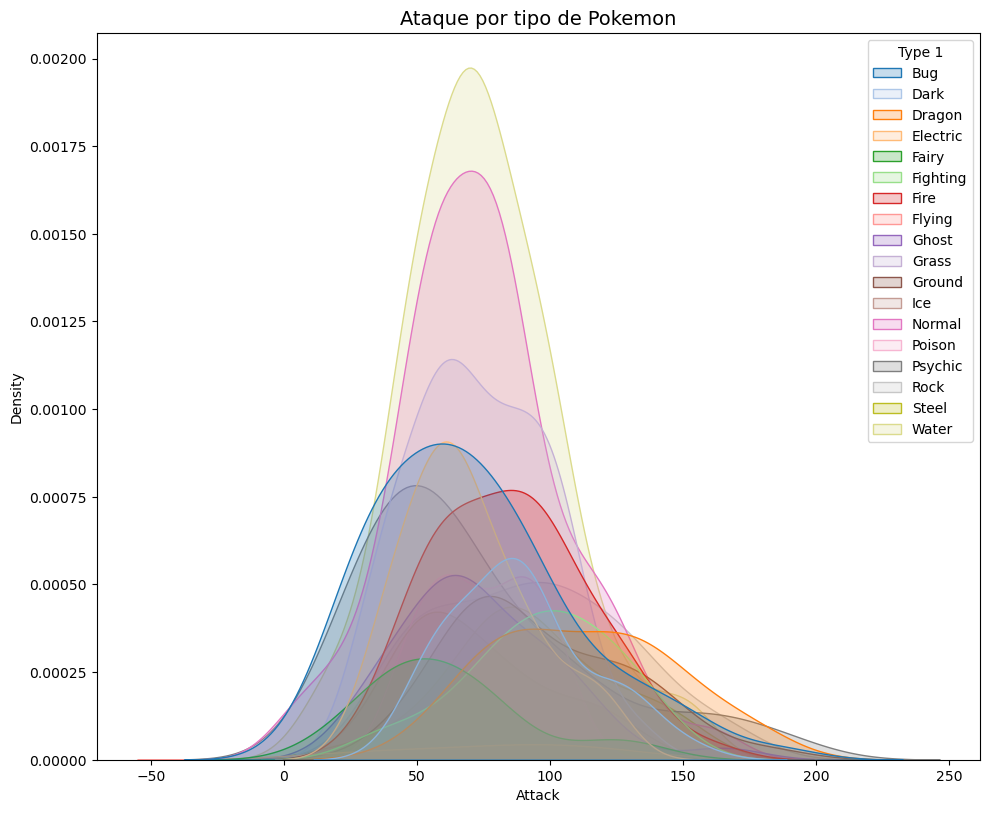

In [21]:
plt.figure(figsize=(10, 8))

sns.kdeplot(data=dt_poke, x='Attack', hue='Type 1', fill=True,
            palette='tab20')
plt.tight_layout()
plt.title('Ataque por tipo de Pokemon', fontsize=14)
plt.show()

In [22]:
# Serie con los valores faltantes
faltantes = dt_poke.isna().sum()

# Calculamos porcentaje de valores faltantes
total_filas = len(dt_poke)
faltantes_df = faltantes.to_frame(name='faltantes')
faltantes_df['porcentaje'] = ((faltantes_df['faltantes'] / total_filas) * 100).round(2)
faltantes_df = faltantes_df.sort_values(by='faltantes', ascending=False)

# Mostramos solo las que tienen valores faltantes
faltantes_df[faltantes_df['faltantes'] > 0]

,faltantes,porcentaje
Type 2,386,48.25


<Axes: >

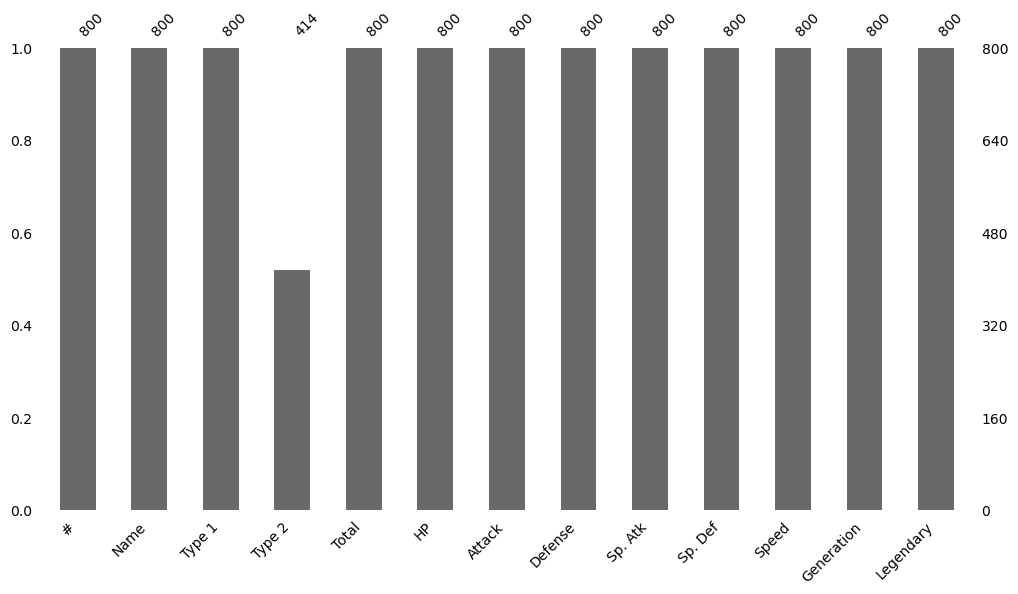

In [23]:
msno.bar(dt_poke, figsize=(12, 6), fontsize=10)